In [20]:
import pandas as pd


In [143]:
# df= pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/archive/bulkSimulationOneProfile/results/fakebulk_reallabels_noexi_noexirealy/master_melted_df.csv.gz", index_col=0)
# df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/real_go_feb2026_allcells/master_melted_df.csv.gz", index_col=0)
# df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/archive/bulkSimulationOneProfile/results/fakebulk_reallabels_noexi_noexirealy_attempt2/master_melted_df.csv.gz")
# df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/real_go_feb2026_noexhi/master_melted_df.csv.gz")
df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/real_go_apr2026_noexi/master_melted_df.csv.gz", index_col=0)
# df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/real_go_feb2026_allcells/master_melted_df.csv.gz", index_col=0)

df['exp'] = df['organism_part'].str.split("_").str[0]
df = df[df.exp=="exp"]
df = df.groupby('index')['auc'].median().reset_index()
df.sort_values("auc")

,index,auc
22,GO:0000423,0.288986
849,GO:0043149,0.324781
1372,GO:2000147,0.330137
492,GO:0016064,0.333917
106,GO:0002437,0.334915
...,...,...
355,GO:0007586,0.727269
361,GO:0007608,0.730891
523,GO:0017158,0.785518
369,GO:0007631,0.791886


In [ ]:
# df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/bulkSimulationOneProfile/results/fakebulk_reallabels_noexi/master_melted_df.csv.gz", index_col=0)
# df2= pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/archive/bulkSimulationOneProfile/results/fakebulk_reallabels_noexi_noexirealy/master_melted_df.csv.gz", index_col=0)
# df2 = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/real_go_feb2026_noexhi/master_melted_df.csv.gz")
# df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/real_go_apr2026_noexi/master_melted_df.csv.gz", index_col=0)

df2['exp'] = df2['organism_part'].str.split("_").str[0]
df2 = df2[df2.exp=="exp"]
df2.sort_values("auc")
df2 = df2.groupby('index')['auc'].median().reset_index()
df2

,index,auc
0,GO:0000045,0.490664
1,GO:0000070,0.527191
2,GO:0000077,0.437425
3,GO:0000079,0.403296
4,GO:0000082,0.528579
...,...,...
1391,GO:2001237,0.604608
1392,GO:2001238,0.699013
1393,GO:2001240,0.569887
1394,GO:2001243,0.566071


In [23]:
merg = df.merge(df2, on="index", suffixes=("_noexi2", "_noexi"))
merg

,index,auc_noexi2,auc_noexi
0,GO:0000045,0.522816,0.490664
1,GO:0000070,0.591019,0.527191
2,GO:0000077,0.604546,0.437425
3,GO:0000079,0.457687,0.403296
4,GO:0000082,0.515754,0.528579
...,...,...,...
1391,GO:2001237,0.592082,0.604608
1392,GO:2001238,0.728213,0.699013
1393,GO:2001240,0.498944,0.569887
1394,GO:2001243,0.554186,0.566071


(0.24359227979406, 0.868271698964768)

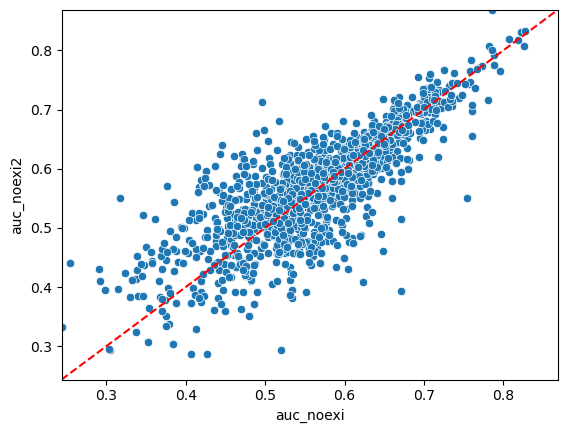

In [24]:
import seaborn as sns
ax = sns.scatterplot(merg, x="auc_noexi", y="auc_noexi2")

lims = [
    min(merg["auc_noexi"].min(), merg["auc_noexi2"].min()),
    max(merg["auc_noexi"].max(), merg["auc_noexi2"].max())
]

ax.plot(lims, lims, color="red", linestyle="--")
ax.set_xlim(lims)
ax.set_ylim(lims)

In [25]:
import anndata as ad
import scanpy as sc
import numpy as np

In [26]:
adata = ad.read_h5ad("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/preprocessing/preprocessSC_pipe/data/h5ad_datasets/processed/cpm/brain_sc_with_metadata_pc_cpm.h5ad")
adata.obs

,cluster,umap_x,umap_y,Tissue,Cluster,Cell type,Cell type group,Cell count,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,norm_factor
0,15,-1.78285,10.86050,Brain,c-15,Inhibitory neurons,Neuronal cells,1993,4379,4379,13035,117,0.897583,13035.0
1,29,4.73990,2.35851,Brain,c-29,Excitatory neurons,Neuronal cells,925,3933,3933,10441,29,0.277751,10441.0
2,10,14.46040,-0.62549,Brain,c-10,Excitatory neurons,Neuronal cells,2401,4656,4656,13994,79,0.564528,13994.0
3,24,6.90615,6.53858,Brain,c-24,Excitatory neurons,Neuronal cells,1293,1507,1507,2612,95,3.637060,2612.0
4,12,5.23585,18.32610,Brain,c-12,Oligodendrocytes,Glial cells,2309,2267,2267,4666,6,0.128590,4666.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76528,12,2.69780,18.02410,Brain,c-12,Oligodendrocytes,Glial cells,2309,1372,1372,2364,2,0.084602,2364.0
76529,2,10.02080,-2.03955,Brain,c-2,Excitatory neurons,Neuronal cells,3732,6039,6039,28839,117,0.405701,28839.0
76530,9,13.34780,5.03476,Brain,c-9,Excitatory neurons,Neuronal cells,2451,1189,1189,1867,4,0.214247,1867.0
76531,12,3.04571,16.96410,Brain,c-12,Oligodendrocytes,Glial cells,2309,1561,1561,2943,32,1.087326,2943.0


In [27]:
exci = adata[adata.obs.loc[:,'Cell type']== "Excitatory neurons"]
exci_mean = exci.X.mean(axis = 0)
exci = pd.DataFrame(exci_mean, index = exci.var.index, columns = ['exci'])

In [28]:
non = adata[adata.obs.loc[:,'Cell type']!= "Excitatory neurons"]
non_mean = non.X.mean(axis = 0)
non = pd.DataFrame(non_mean, index = non.var.index, columns = ['non'])

In [29]:
both = exci.merge(non, left_index=True, right_index=True)
both['fc'] = both['exci']/both['non']
both['log2fc'] = np.log2(both['fc'])
both.sort_values('log2fc')
t=both[both.log2fc > 1]

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [30]:
t

,exci,non,fc,log2fc
ensembl_gene_id,,,,
ENSG00000002746,720.579712,188.021744,3.832428,1.938259
ENSG00000003137,6.923940,0.909390,7.613828,2.928622
ENSG00000004399,14.694117,5.480503,2.681162,1.422858
ENSG00000004660,73.252739,17.873678,4.098358,2.035046
ENSG00000005001,0.016030,0.006083,2.634961,1.397782
...,...,...,...,...
ENSG00000283361,1.913884,0.343418,5.573046,2.478466
ENSG00000284609,0.057187,0.000000,inf,inf
ENSG00000284680,0.004828,0.000000,inf,inf


In [31]:
import scanpy as sc
# Basic normalization
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Save normalized data in adata.raw (recommended)
adata.raw = adata

# Define the group of interest
group = "Excitatory neurons"

# Create a binary label: ONE vs ALL
adata.obs["one_vs_all"] = (
    adata.obs["Cell type"].eq(group)
).astype(str)

# keep genes expressed in at least 5 cells OR in at least 5% of the target group
from scipy import sparse
import numpy as np

# compute fraction expressed in the True group
def frac_expr(adata_sub):
    X = adata_sub.X
    if sparse.issparse(X):
        return (X.astype(bool).sum(axis=0).A1 / X.shape[0])
    else:
        return (np.count_nonzero(X, axis=0) / X.shape[0])

frac_true = frac_expr(adata[adata.obs["one_vs_all"] == "True"])

# thresholds
min_cells = 100
min_frac_in_group = 0.1

# keep genes expressed in >= min_cells in entire dataset
if sparse.issparse(adata.X):
    keep = (adata.X.astype(bool).sum(axis=0).A1 >= min_cells)
else:
    keep = (np.count_nonzero(adata.X, axis=0) >= min_cells)

# also keep genes expressed in >= 5% of the target group
keep = keep | (frac_true >= min_frac_in_group)

print("Kept genes:", keep.sum(), "of", adata.shape[1])

# filter
adata = adata[:, keep].copy()
# sc.pp.filter_genes(adata, min_cells=5)

# Run differential expression (wilcoxon)
sc.tl.rank_genes_groups(
    adata,
    groupby="one_vs_all",
    method="wilcoxon",
    reference="rest"       # one vs all
)

# Extract results into a table
deg = sc.get.rank_genes_groups_df(adata, group="True")
deg.head()


Kept genes: 16334 of 17724


/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,names,scores,logfoldchanges,pvals,pvals_adj
0,ENSG00000185518,226.082550,5.747296,0.0,0.0
1,ENSG00000119042,224.349411,6.378094,0.0,0.0
2,ENSG00000081803,216.986740,5.981803,0.0,0.0
3,ENSG00000112137,216.873322,2.329651,0.0,0.0
4,ENSG00000128656,215.610840,2.843074,0.0,0.0


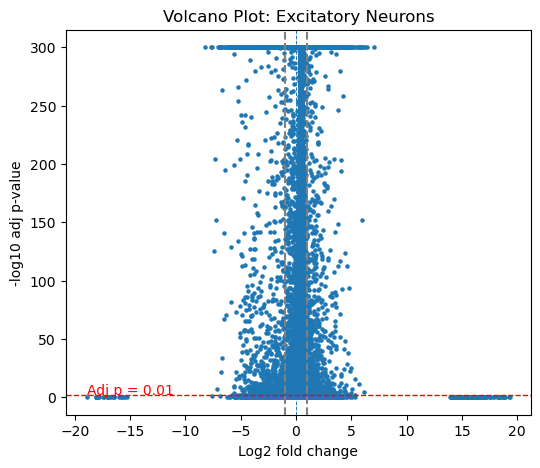

In [32]:
import numpy as np
import matplotlib.pyplot as plt

deg = sc.get.rank_genes_groups_df(adata, group="True")

x = deg["logfoldchanges"]
y = -np.log10(deg["pvals_adj"] + 1e-300)

plt.figure(figsize=(6,5))
plt.scatter(x, y, s=5)

# significance line @ adj p-value = 0.05
p_thresh = 0.01
yline = -np.log10(p_thresh)

plt.axhline(yline, color="red", linestyle="--", linewidth=1)
plt.text(
    x.min(), 
    yline + 0.1, 
    f"Adj p = {p_thresh}", 
    color="red", 
    fontsize=10
)
plt.axvline(1, color="gray", linestyle="--")
plt.axvline(-1, color="gray", linestyle="--")

plt.xlabel("Log2 fold change")
plt.ylabel("-log10 adj p-value")
plt.title("Volcano Plot: Excitatory Neurons")

plt.axvline(0, linestyle="--", linewidth=0.7)
plt.show()


In [33]:
# dea = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/deconvolutingBulk/bin/notebooks/all_gene_marker_scores.csv", index_col=0)
# dea = dea[dea.loc[:,'group'] == "Excitatory neurons" ]
# dea = dea[dea.pvals_adj <=0.01]
# dea = dea[dea.logfoldchanges < -1]
# dea.sort_values("pvals_adj")

In [34]:
# dea = dea[dea.pvals_adj <=0.01]
# dea = dea[dea.logfoldchanges < -1]

In [201]:
dea =  deg[deg.pvals_adj <=0.01]
dea = dea[dea.logfoldchanges > 2 ]
dea

,names,scores,logfoldchanges,pvals,pvals_adj
0,ENSG00000185518,226.082550,5.747296,0.000000,0.000000
1,ENSG00000119042,224.349411,6.378094,0.000000,0.000000
2,ENSG00000081803,216.986740,5.981803,0.000000,0.000000
3,ENSG00000112137,216.873322,2.329651,0.000000,0.000000
4,ENSG00000128656,215.610840,2.843074,0.000000,0.000000
...,...,...,...,...,...
10588,ENSG00000139780,2.884893,3.808833,0.003915,0.005523
10593,ENSG00000138435,2.875535,2.509429,0.004033,0.005686
10620,ENSG00000139053,2.829140,3.967074,0.004667,0.006560
10676,ENSG00000214414,2.706127,4.894691,0.006807,0.009509


In [202]:
# Load GO term annotations
go_annot_path = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/preprocessing/preprocessGO_pipe/data/2024_march/data/processing/bp_annotations_withGeneData_qc_annotations.csv"
go_annot = pd.read_csv(go_annot_path)
go_annot = go_annot.loc[:,["GO ID", "DB_Object_Symbol", "ensembl_gene_id"]]
go_annot

,GO ID,DB_Object_Symbol,ensembl_gene_id
0,GO:0000045,IRGM,ENSG00000237693
1,GO:0000045,BECN2,ENSG00000196289
2,GO:0000045,AP4M1,ENSG00000221838
3,GO:0000045,ATG13,ENSG00000175224
4,GO:0000045,ULK1,ENSG00000177169
...,...,...,...
76885,GO:2001244,BOK,ENSG00000176720
76886,GO:2001244,PLAGL2,ENSG00000126003
76887,GO:2001244,FIS1,ENSG00000214253
76888,GO:2001244,RIPK3,ENSG00000285379


In [203]:
# get size of each GO
go_sizes = go_annot.groupby("GO ID").size().reset_index(name = 'size')
go_sizes

,GO ID,size
0,GO:0000045,63
1,GO:0000070,33
2,GO:0000077,35
3,GO:0000079,52
4,GO:0000082,64
...,...,...
1397,GO:2001237,37
1398,GO:2001238,27
1399,GO:2001240,34
1400,GO:2001243,23


In [204]:
# get number of exi genes in each GO
n_in  = pd.merge(go_annot, dea, left_on = "ensembl_gene_id", right_on='names').groupby("GO ID").size().reset_index(name = 'size_in')
n_in.sort_values('size_in')

,GO ID,size_in
919,GO:2001243,1
608,GO:0045596,1
609,GO:0045597,1
300,GO:0010881,1
298,GO:0010842,1
...,...,...
248,GO:0008285,18
264,GO:0009410,19
145,GO:0006954,19
247,GO:0008284,19


In [205]:
percent = pd.merge(go_sizes, n_in, on = "GO ID")
percent['percent'] = percent['size_in']/percent['size']
# percent['percent'] = percent['size_in']
percent.sort_values(by = 'percent')

,GO ID,size,size_in,percent
149,GO:0006974,257,1,0.003891
755,GO:0051726,222,1,0.004505
87,GO:0006325,215,1,0.004651
254,GO:0008380,171,1,0.005848
246,GO:0008283,148,1,0.006757
...,...,...,...,...
724,GO:0050919,39,7,0.179487
581,GO:0043542,33,6,0.181818
447,GO:0032332,20,4,0.200000
211,GO:0007422,25,5,0.200000


In [227]:
# df_plot = pd.DataFrame(df.groupby(['index'])['auc'].median()).reset_index()
df_plot = df.copy()
print(df_plot.shape)
df_plot.columns = ["GO ID", "auc"]
df_plot = df_plot.merge(percent, on = "GO ID", how = 'left')
df_plot = df_plot[df_plot.size_in>0]
df_plot['percent'] = df_plot['percent'].fillna(0)
df_plot.sort_values('auc')
df_plot.sort_values("auc", ascending=False)
df_plot = df_plot[df_plot.loc[:,'GO ID']!= "GO:0050911"]
print(df_plot.shape)

(1396, 2)
(917, 5)


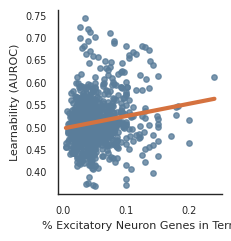

In [215]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Compute linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_plot['percent'], df_plot['auc'])
r_squared = r_value**2

# Set Seaborn style and context for publication
sns.set_theme(style="white", palette="muted")
sns.set_context("paper")

# Create figure
fig, ax = plt.subplots(figsize=(2.5,2.5))

# Scatter plot with regression line
sns.regplot(
    data=df_plot,
    x='percent',
    y='auc',
    ci=None,            # remove confidence interval
    scatter_kws={'s':15, 'color':'#5A7D9A', 'alpha':0.8},  # marker size and color
    line_kws={'color':'#D5723F', 'lw':3},                 # regression line color and thickness
    ax=ax
)

# Add R^2 and p-value
# ax.text(
#     0.05, 0.95,
#     f"$R^2$ = {r_squared:.3f}\np = {p_value:.3g}",
#     transform=ax.transAxes,
#     verticalalignment='top',
#     fontsize=10
# )

# Label axes
ax.set_xlabel('% Excitatory Neuron Genes in Term', fontsize=8)
ax.set_ylabel('Learnability (AUROC)', fontsize=8)
# Make tick labels smaller
ax.tick_params(axis='x', labelsize=7)  # x-axis tick labels
ax.tick_params(axis='y', labelsize=7)  # y-axis tick labels
# ax.set_title('Regression of AUC vs Percent', fontsize=12)

# Tidy up spines
sns.despine(ax=ax)

# Save publication-ready figure
plt.tight_layout()
plt.savefig("results/auc_vs_percent_noexi.pdf", transparent=True)
plt.savefig("results/auc_vs_percent_noexi.png", dpi=300, transparent=True)
plt.show()

In [228]:
df_plot

,GO ID,auc,size,size_in,percent
0,GO:0000045,0.532480,63.0,2.0,0.031746
1,GO:0000070,0.480277,33.0,2.0,0.060606
3,GO:0000079,0.466102,52.0,1.0,0.019231
4,GO:0000082,0.473706,64.0,1.0,0.015625
5,GO:0000086,0.485425,47.0,1.0,0.021277
...,...,...,...,...,...
1382,GO:2000463,0.655643,29.0,3.0,0.103448
1385,GO:2000773,0.525349,22.0,1.0,0.045455
1389,GO:2001234,0.510846,32.0,3.0,0.093750
1391,GO:2001237,0.468472,37.0,1.0,0.027027


In [216]:
pros_new = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/realgo_noexi_may/1/simulations/0.05/exp_brain_sc_with_metadata_pc_cpm_cell_type_profiles.csv/exp_brain_sc_with_metadata_pc_cpm_cell_type_profiles_.csv.gz", index_col=0)
pros_new.mean(axis=1)

ENSG00000000003     11783.98707
ENSG00000000005        22.56957
ENSG00000000419     45919.89604
ENSG00000000457     22596.01600
ENSG00000000460     26086.92789
                       ...     
ENSG00000286237     68641.76527
ENSG00000287542    120936.83763
ENSG00000288602     29191.25912
ENSG00000288649        89.75635
ENSG00000288675      1744.02265
Length: 17724, dtype: float64

In [217]:
pros_old = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/archive/bulkSimulationOneProfile/results/fakebulk_reallabels_noexi_noexirealy_attempt2/1/simulations/0.05/exp_brain_sc_with_metadata_pc_cpm_cell_type_profiles.csv/exp_brain_sc_with_metadata_pc_cpm_cell_type_profiles_.csv.gz", index_col=0)
pros_old.mean(axis = 1)

ENSG00000000003     14346.41445
ENSG00000000005        27.29137
ENSG00000000419     55731.54177
ENSG00000000457     27451.15858
ENSG00000000460     31689.42306
                       ...     
ENSG00000286237     83310.35274
ENSG00000287542    146672.44182
ENSG00000288602     35446.57012
ENSG00000288649       108.41003
ENSG00000288675      2122.43855
Length: 17724, dtype: float64

In [94]:
pros_new.mean(axis=1)

ENSG00000000003     11843.91108
ENSG00000000005        22.46811
ENSG00000000419     45913.80640
ENSG00000000457     22610.44913
ENSG00000000460     26055.52117
                       ...     
ENSG00000286237     68616.53752
ENSG00000287542    120748.48795
ENSG00000288602     29209.58499
ENSG00000288649        89.25633
ENSG00000288675      1752.80120
Length: 17724, dtype: float64

In [93]:
pros_old.mean(axis=1)

ENSG00000000003     14346.41445
ENSG00000000005        27.29137
ENSG00000000419     55731.54177
ENSG00000000457     27451.15858
ENSG00000000460     31689.42306
                       ...     
ENSG00000286237     83310.35274
ENSG00000287542    146672.44182
ENSG00000288602     35446.57012
ENSG00000288649       108.41003
ENSG00000288675      2122.43855
Length: 17724, dtype: float64

In [66]:
pros_new.mean(axis=0)

0     56420.672509
1     56420.672501
2     56420.672504
3     56420.672501
4     56420.672506
          ...     
95    56420.672499
96    56420.672499
97    56420.672499
98    56420.672504
99    56420.672504
Length: 100, dtype: float64

In [67]:
pros_old.mean(axis=0)

0     69522.982539
1     70522.245818
2     67366.026284
3     68909.949003
4     66877.743293
          ...     
95    66213.767708
96    67989.365878
97    68246.660957
98    69002.128553
99    69914.603385
Length: 100, dtype: float64

In [78]:
t = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/archive/bulkSimulationOneProfile/results/fakebulk_reallabels_noexi_noexirealy_attempt2/1/simulations/0.05/exp_brain_sc_with_metadata_pc_cpm_cell_type_profiles.csv/exp_brain_sc_with_metadata_pc_cpm_cell_type_profiles_n_sim_4_profiles.csv",index_col=0)
t.sum()

0    1185.341123
dtype: float64

In [89]:
t_new = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/realgo_noexi_may/1/simulations/0.05/exp_brain_sc_with_metadata_pc_cpm_cell_type_profiles.csv/exp_brain_sc_with_metadata_pc_cpm_cell_type_profiles_n_sim_12_profiles.csv",index_col=0)
t_new.sum()

0    1000
dtype: int64

<Axes: xlabel='auc_old', ylabel='auc_new'>

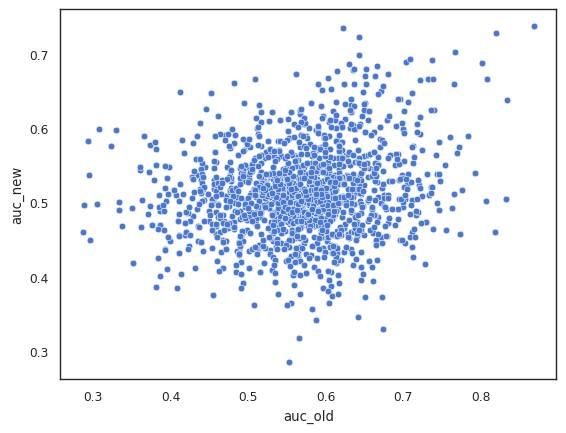

In [113]:
old = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/archive/bulkSimulationOneProfile/results/fakebulk_reallabels_noexi_noexirealy_attempt2/master_melted_df.csv.gz").query("organism_part.str.contains('exp')", engine='python'	)
new = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/realgo_noexi_may/master_melted_df.csv.gz", index_col=0).query("organism_part.str.contains('exp')", engine='python'	)
merged = old.merge(new, on="index", suffixes=("_old", "_new"))

sns.scatterplot(merged, x="auc_old", y="auc_new")

In [127]:
merged['diff'] = merged['auc_new'] - merged['auc_old']
merged.query('auc_old>0.7').sort_values('diff', ascending=False)

,Unnamed: 0,index,organism_part_old,bootstrap_old,variance_old,auc_old,organism_part_new,bootstrap_new,variance_new,auc_new,diff
806,806,GO:0042178,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.703542,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.689047,-0.014495
834,834,GO:0042755,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.708007,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.693374,-0.014632
1146,1146,GO:0051932,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.737228,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.691635,-0.045594
319,319,GO:0007269,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.721808,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.664493,-0.057314
318,318,GO:0007268,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.710669,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.646723,-0.063946
...,...,...,...,...,...,...,...,...,...,...,...
1277,1277,GO:0090050,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.807107,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.502203,-0.304904
1393,1393,GO:2001238,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.728213,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.417747,-0.310466
777,777,GO:0035924,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.773395,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.457870,-0.315524
236,236,GO:0006911,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.831829,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,1,0.05,0.504810,-0.327019


In [291]:
# df_plot = pd.DataFrame(df.groupby(['index'])['auc'].median()).reset_index()
df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/realgo_noexi_may/master_melted_df.csv.gz", index_col=0)
# df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/real_go_feb2026_allcells/master_melted_df.csv.gz", index_col=0)
df['exp'] = df['organism_part'].str.split("_").str[0]
df = df.query('exp == "exp"')
df = df.query('variance==0.05')
df = df.groupby('index')['auc'].mean().reset_index()

print(df.shape)


df_plot = df.loc[:,["index", "auc"]].copy()
df_plot.columns = ["GO ID", "auc"]
df_plot = df_plot.merge(percent, on = "GO ID", how = 'left')
# df_plot = df_plot[df_plot.percent>=0.05]
# df_plot = df_plot[df_plot.size_in>3]
df_plot['percent'] = df_plot['percent'].fillna(0)
df_plot.sort_values('auc')
df_plot.sort_values("auc", ascending=False)
df_plot = df_plot[df_plot.loc[:,'GO ID']!= "GO:0050911"]
print(df_plot.shape)

(1396, 2)
(1395, 5)


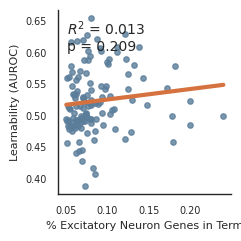

In [288]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Compute linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_plot['percent'], df_plot['auc'])
r_squared = r_value**2

# Set Seaborn style and context for publication
sns.set_theme(style="white", palette="muted")
sns.set_context("paper")

# Create figure
fig, ax = plt.subplots(figsize=(2.5,2.5))

# Scatter plot with regression line
sns.regplot(
    data=df_plot,
    x='percent',
    y='auc',
    ci=None,            # remove confidence interval
    scatter_kws={'s':15, 'color':'#5A7D9A', 'alpha':0.8},  # marker size and color
    line_kws={'color':'#D5723F', 'lw':3},                 # regression line color and thickness
    ax=ax
)

# Add R^2 and p-value
ax.text(
    0.05, 0.95,
    f"$R^2$ = {r_squared:.3f}\np = {p_value:.3g}",
    transform=ax.transAxes,
    verticalalignment='top',
    fontsize=10
)

# Label axes
ax.set_xlabel('% Excitatory Neuron Genes in Term', fontsize=8)
ax.set_ylabel('Learnability (AUROC)', fontsize=8)
# Make tick labels smaller
ax.tick_params(axis='x', labelsize=7)  # x-axis tick labels
ax.tick_params(axis='y', labelsize=7)  # y-axis tick labels
# ax.set_title('Regression of AUC vs Percent', fontsize=12)

# Tidy up spines
sns.despine(ax=ax)

# Save publication-ready figure
plt.tight_layout()
plt.savefig("results/auc_vs_percent_noexi.pdf", transparent=True)
plt.savefig("results/auc_vs_percent_noexi.png", dpi=300, transparent=True)
plt.show()